In [1]:
/env/bin/python -m pip install pymannkendall 

In [57]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose


from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)

In [61]:
csv_path = "28.csv"                    #ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
df = pd.read_csv(csv_path)

# Convert date and sort
df["TIME"] = pd.to_datetime(df["TIME"])          # convert to datetime
df = df.set_index("TIME")                        # set TIME as index

pv = df.PV.resample('MS').mean().interpolate(method='cubic')

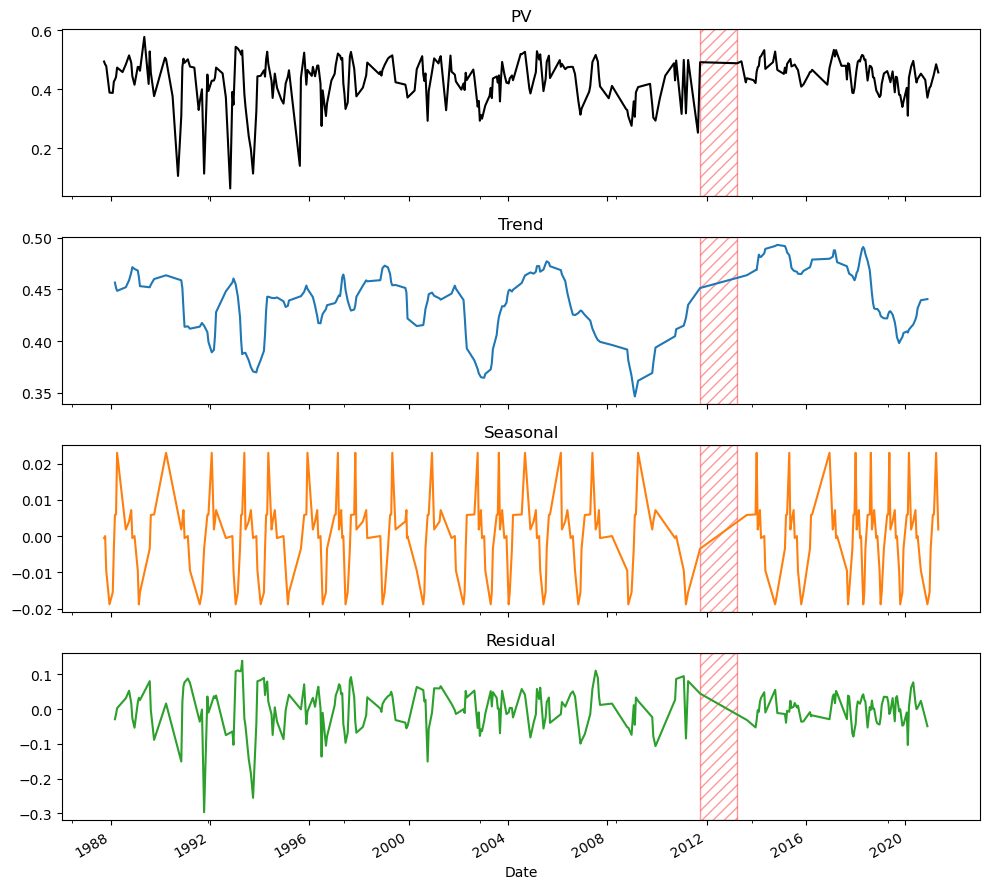

In [62]:
df.columns
df = df.reset_index()

#Ensure TIME is datetime
df["TIME"] = pd.to_datetime(df["TIME"])

# Use TIME as index
pv = df.set_index("TIME")["PV"].astype(float)

# Find gaps larger than 365 days
gaps = pv.index.to_series().diff().dt.days
gap_ranges = []
for i in range(1, len(gaps)):
    if gaps.iloc[i] > 365:
        gap_ranges.append((pv.index[i - 1], pv.index[i]))

# Remove the large-gap data for decomposition
pv_filtered = pv.loc[gaps.fillna(1) < 60]

# Decompose
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend = result.trend
seasonal = result.seasonal
resid = result.resid

# Plot (matching your smoothed version style)
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
pv.plot(ax=axes[0], title="PV", color="black")
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

# Shade the missing gaps with red hatched blocks
for ax in axes:
    for start, end in gap_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="red", hatch="///", alpha=0.4)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

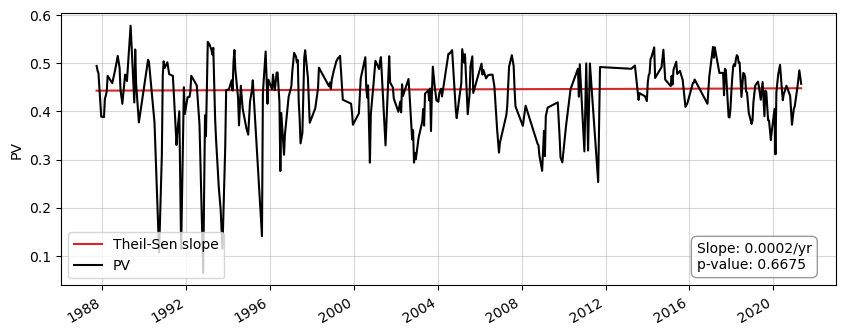

In [63]:
def mk_with_slopes(y, alpha = 0.05):
    """
    This function checks the Mann-Kendall (MK) test (Mann 1945, Kendall 1975, Gilbert 1987).
    This was modified from the "pymannkendall" library to return fewer statistics which makes
    it a little more robust.
    
    Input:
        x: a vector (list, numpy array or pandas series) data
        alpha: significance level (0.05 default)
    Output:
        p: p-value of the significance test
        slope: Theil-Sen estimator/slope
        intercept: intercept of Kendall-Theil Robust Line
        
    """
    res = namedtuple('Mann_Kendall_Test', ['p','slope','intercept'])
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method = 'skip')
    
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)

    return res(p, slope, intercept)

# slope, intercept, lo_slope, up_slope = theilslopes(y, x, 0.95)
p, slope, intercept = mk_with_slopes(pv)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

y = range(0, len(pv)) * slope + intercept
ax.plot(date2num(pv.index), y, color='tab:red', label='Theil-Sen slope');

pv.plot(ax=ax, label='PV', color="black")
ax.set_ylabel('PV')
ax.set_xlabel(None)
ax.grid(alpha=0.5);

# Annotate slope and p-value as nice text box
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.legend(loc='lower left');